A partir de la mejora del modelo, se ampliaron los modelos supervisados iniciales (Regresión Lineal, Random Forest y Gradient Boosting), incorporando nuevos enfoques. Esto permitió analizar el problema desde distintas perspectivas, especialmente capturando relaciones no lineales y reduciendo posibles problemas de sobreajuste.

Todos los modelos se evaluaron bajo las mismas métricas (MAPE y R²), lo que permitió realizar una comparación objetiva y seleccionar el más adecuado.

Adicionalmente, en el análisis no supervisado se aplicó el método del codo, identificando 3 clusters óptimos, lo cual permitió segmentar los departamentos según su comportamiento en homicidios y educación.

# Predicción de la tasa de homicidios en Colombia a partir de variables educativas

**Estudiantes:** Diana Vaelntina Ordoñez Prieto , Juan Diego Avila , Angie Mariana Pedraza Pedraza
**Curso:** Proyecto en Analitica Aplicada
**Docente:** Andres Ortega 
**Fecha:** 14/04/2026



## Introducción

En este proyecto se analiza la relación entre factores educativos y la tasa de homicidios en Colombia. Para ello, se construye un modelo de aprendizaje supervisado que permita predecir la tasa de homicidios a partir de variables educativas registradas por departamento y año.

El problema se aborda como una tarea de **regresión**, ya que la variable de salida es continua. Además del componente predictivo, el proyecto busca aportar una interpretación sobre la posible asociación entre educación y violencia.

## Carga de datos

En esta sección se realiza la carga del conjunto de datos que contiene información sobre variables educativas y la tasa de homicidios en Colombia.

El archivo es importado utilizando la librería **pandas**, lo que permite manipular y analizar los datos de manera eficiente. Este dataset constituye la base del análisis y del desarrollo del modelo predictivo.

Se asume que los datos están organizados por departamento y año, incluyendo variables relevantes para el estudio de la relación entre educación y violencia.

In [26]:
import pandas as pd
import numpy as np

# Base cruda indicada para el proyecto.
homicidios = pd.read_excel("HOMICIDIO_con_Poblacion_Final.xlsx")

print("Filas base cruda:", len(homicidios))
print("Años disponibles:", homicidios["FECHA HECHO"].dt.year.min(), "-", homicidios["FECHA HECHO"].dt.year.max())
display(homicidios.head())

Filas base cruda: 334537
Años disponibles: 2003 - 2025


,FECHA HECHO,COD_DEPTO,DEPARTAMENTO,COD_MUNI,MUNICIPIO,ZONA,SEXO,CANTIDAD
0,2003-01-01,11,BOGOTA D.C.,11001,BOGOTA D.C.,URBANA,MASCULINO,1
1,2003-01-01,11,BOGOTA D.C.,11001,BOGOTA D.C.,URBANA,MASCULINO,1
2,2003-01-01,11,BOGOTA D.C.,11001,BOGOTA D.C.,URBANA,MASCULINO,1
3,2003-01-01,11,BOGOTA D.C.,11001,BOGOTA D.C.,URBANA,MASCULINO,1
4,2003-01-01,11,BOGOTA D.C.,11001,BOGOTA D.C.,URBANA,MASCULINO,1


## Unión de homicidios con población

Se unen las bases `HOMICIDIO_con_Poblacion_Final.xlsx` y `Poblacion.xlsx` mediante un `inner join`. La base de homicidios se agrupa por año, departamento y zona, sumando `CANTIDAD`. Además, se elimina la columna `SEXO` y se homologan las zonas: `URBANA` con `Cabecera`, y `RURAL` con `Centros Poblados y Rural Disperso`.

In [27]:
# Si esta celda se ejecuta de forma independiente, se carga la base cruda.
try:
    homicidios
except NameError:
    homicidios = pd.read_excel("HOMICIDIO_con_Poblacion_Final.xlsx")

poblacion = pd.read_excel("Poblacion.xlsx", sheet_name="Poblacion_DP")
homicidios = homicidios.copy()

# Eliminar la columna solicitada antes de agrupar.
homicidios = homicidios.drop(columns=["SEXO"], errors="ignore")

# Llave temporal: FECHA HECHO se lleva a año para unirla con AÑO.
homicidios["AÑO"] = pd.to_datetime(homicidios["FECHA HECHO"], errors="coerce").dt.year.astype("Int64")

# Homologar ZONA con AREA GEOGRAFICA de la base de poblacion.
mapa_zona_area = {
    "URBANA": "Cabecera",
    "RURAL": "Centros Poblados y Rural Disperso",
}
homicidios["AREA_GEOGRAFICA_JOIN"] = (
    homicidios["ZONA"]
    .astype(str)
    .str.strip()
    .str.upper()
    .map(mapa_zona_area)
)

poblacion["ÁREA GEOGRÁFICA"] = poblacion["ÁREA GEOGRÁFICA"].astype(str).str.strip()
poblacion["ÁREA GEOGRÁFICA"] = poblacion["ÁREA GEOGRÁFICA"].replace({
    "Cabecera Municipal": "Cabecera",
})

# Sumar la cantidad de homicidios por año, departamento y zona/area geografica.
homicidios_agrupados = (
    homicidios
    .dropna(subset=["AÑO", "COD_DEPTO", "AREA_GEOGRAFICA_JOIN"])
    .groupby(["AÑO", "COD_DEPTO", "DEPARTAMENTO", "ZONA", "AREA_GEOGRAFICA_JOIN"], as_index=False)
    ["CANTIDAD"]
    .sum()
    .rename(columns={"CANTIDAD": "CANTIDAD_HOMICIDIOS"})
)

poblacion_filtrada = poblacion[
    poblacion["ÁREA GEOGRÁFICA"].isin(mapa_zona_area.values())
].copy()

base_homicidio_poblacion = homicidios_agrupados.merge(
    poblacion_filtrada,
    left_on=["COD_DEPTO", "AÑO", "AREA_GEOGRAFICA_JOIN"],
    right_on=["DP", "AÑO", "ÁREA GEOGRÁFICA"],
    how="inner",
)

base_homicidio_poblacion = base_homicidio_poblacion.drop(columns=["AREA_GEOGRAFICA_JOIN"])
base_homicidio_poblacion.to_excel("HOMICIDIO_Poblacion_InnerJoin.xlsx", index=False)

print("Filas base homicidios agrupada:", len(homicidios_agrupados))
print("Filas despues del inner join:", len(base_homicidio_poblacion))
display(base_homicidio_poblacion.head())

Filas base homicidios agrupada: 1470
Filas despues del inner join: 1345


,AÑO,COD_DEPTO,DEPARTAMENTO,ZONA,CANTIDAD_HOMICIDIOS,DP,DPNOM,ÁREA GEOGRÁFICA,Población
0,2005,5,ANTIOQUIA,RURAL,901,5,Antioquia,Centros Poblados y Rural Disperso,1423748
1,2005,5,ANTIOQUIA,URBANA,1294,5,Antioquia,Cabecera,4037095
2,2005,8,ATLANTICO,RURAL,47,8,Atlántico,Centros Poblados y Rural Disperso,111121
3,2005,8,ATLANTICO,URBANA,536,8,Atlántico,Cabecera,2003015
4,2005,11,BOGOTA D.C.,RURAL,12,11,"Bogotá, D.C.",Centros Poblados y Rural Disperso,16216


## Unión de homicidios, población y educación

Se agrupa `HOMICIDIO_Poblacion_InnerJoin.xlsx` por año y departamento para sumar las zonas rural y urbana. Luego se agrupa `nueva base.csv` por las mismas llaves y se realiza un `inner join` usando `AÑO`/`COD_DEPTO` con `AÃ‘O`/`CÃ³digo delDepartamento`.

In [28]:
homicidio_poblacion = pd.read_excel("HOMICIDIO_Poblacion_InnerJoin.xlsx")
educacion = pd.read_csv("nueva base.csv", encoding="latin1")

# El CSV viene con mojibake en los dos primeros encabezados.
# Se toman por posicion para no depender del caracter corrupto de "AÑO".
col_anio_educacion = educacion.columns[0]
col_depto_educacion = educacion.columns[1]

educacion[col_anio_educacion] = pd.to_numeric(educacion[col_anio_educacion], errors="coerce").astype("Int64")
educacion[col_depto_educacion] = pd.to_numeric(educacion[col_depto_educacion], errors="coerce").astype("Int64")
educacion = educacion.dropna(subset=[col_anio_educacion, col_depto_educacion])

# Sumar Rural y Urbana por año y departamento.
homicidio_poblacion_agrupada = (
    homicidio_poblacion
    .groupby(["AÑO", "COD_DEPTO"], as_index=False)
    .agg({
        "DEPARTAMENTO": "first",
        "DPNOM": "first",
        "CANTIDAD_HOMICIDIOS": "sum",
        "Población": "sum",
    })
)

columnas_educacion = [
    "TECNICA PROFESIONAL",
    "TECNOLOGICA",
    "UNIVERSITARIA",
    "ESPECIALIZACION",
    "MAESTRIA",
    "DOCTORADO",
]

for columna in columnas_educacion:
    educacion[columna] = pd.to_numeric(educacion[columna], errors="coerce").fillna(0)

educacion_agrupada = (
    educacion
    .groupby([col_anio_educacion, col_depto_educacion], as_index=False)
    .agg({
        "Nombre del Departamento": "first",
        **{columna: "sum" for columna in columnas_educacion},
    })
)

base_homicidio_poblacion_educacion = homicidio_poblacion_agrupada.merge(
    educacion_agrupada,
    left_on=["AÑO", "COD_DEPTO"],
    right_on=[col_anio_educacion, col_depto_educacion],
    how="inner",
)

base_homicidio_poblacion_educacion = base_homicidio_poblacion_educacion.drop(
    columns=[col_anio_educacion, col_depto_educacion]
)
base_homicidio_poblacion_educacion.to_excel(
    "HOMICIDIO_Poblacion_Educacion_InnerJoin.xlsx",
    index=False,
)

# Tabla final usada por los modelos. Evita depender de un archivo intermedio antiguo.
df = base_homicidio_poblacion_educacion.rename(columns={
    "AÑO": "año",
    "DEPARTAMENTO": "departamento",
    "CANTIDAD_HOMICIDIOS": "homicidios",
    "Población": "poblacion",
})
df["departamento"] = df["departamento"].astype(str).str.strip().str.upper()
df["año"] = pd.to_numeric(df["año"], errors="coerce").astype("Int64")
df["homicidios"] = pd.to_numeric(df["homicidios"], errors="coerce")
df["poblacion"] = pd.to_numeric(df["poblacion"], errors="coerce")
df["tasa_homicidios_100k"] = (df["homicidios"] / df["poblacion"]) * 100000

columnas_modelo = [
    "departamento", "año", "homicidios", "poblacion",
    *columnas_educacion, "tasa_homicidios_100k"
]
df = df[columnas_modelo].dropna(subset=["departamento", "año", "poblacion", "tasa_homicidios_100k"])
df = df.sort_values(["departamento", "año"]).reset_index(drop=True)

print("Filas homicidio+poblacion agrupada:", len(homicidio_poblacion_agrupada))
print("Filas educacion agrupada:", len(educacion_agrupada))
print("Filas despues del inner join:", len(base_homicidio_poblacion_educacion))
print("Departamentos en df final:", df["departamento"].nunique())
print("Años en df final:", df["año"].min(), "-", df["año"].max())
display(df.head())

Filas homicidio+poblacion agrupada: 689
Filas educacion agrupada: 561
Filas despues del inner join: 558
Departamentos en df final: 33
Años en df final: 2005 - 2021


,departamento,año,homicidios,poblacion,TECNICA PROFESIONAL,TECNOLOGICA,UNIVERSITARIA,ESPECIALIZACION,MAESTRIA,DOCTORADO,tasa_homicidios_100k
0,AMAZONAS,2005,11,59580,226.0,0.0,418.0,4.0,78.0,0.0,18.462571
1,AMAZONAS,2006,10,60784,332.0,56.0,560.0,6.0,50.0,0.0,16.451698
2,AMAZONAS,2007,8,62028,476.0,214.0,246.0,10.0,78.0,0.0,12.897401
3,AMAZONAS,2008,9,63291,438.0,370.0,188.0,66.0,92.0,0.0,14.220031
4,AMAZONAS,2009,6,64616,258.0,974.0,676.0,36.0,88.0,0.0,9.285626


## Organización de los datos

Se ordenan los datos por departamento y año para facilitar su análisis y asegurar una estructura temporal coherente.

Esto permite observar la evolución de la tasa de homicidios en cada región a lo largo del tiempo.

In [29]:
df = df.sort_values(["departamento", "año"])
print(df[["departamento", "año", "tasa_homicidios_100k"]].head(20))

   departamento   año  tasa_homicidios_100k
0      AMAZONAS  2005             18.462571
1      AMAZONAS  2006             16.451698
2      AMAZONAS  2007             12.897401
3      AMAZONAS  2008             14.220031
4      AMAZONAS  2009              9.285626
5      AMAZONAS  2010             15.153582
6      AMAZONAS  2011             16.329924
7      AMAZONAS  2012             14.560068
8      AMAZONAS  2013             14.295313
9      AMAZONAS  2014             26.679773
10     AMAZONAS  2015             12.416362
11     AMAZONAS  2016             23.038352
12     AMAZONAS  2017              6.657435
13     AMAZONAS  2018             10.447547
14     AMAZONAS  2019              7.685903
15     AMAZONAS  2020              8.795848
16     AMAZONAS  2021             29.679095
17    ANTIOQUIA  2005             40.195259
18    ANTIOQUIA  2006             37.499179
19    ANTIOQUIA  2007             34.779936


## Selección de variables

Se construye un subconjunto de datos con las variables relevantes para el análisis, incluyendo la tasa de homicidios y los niveles educativos.

Esto permite enfocar el modelo en las variables que pueden influir directamente en el comportamiento de la variable objetivo.

In [30]:
analisis_panel = df[[
    "departamento",
    "año",
    "tasa_homicidios_100k",
    "TECNICA PROFESIONAL",
    "TECNOLOGICA",
    "UNIVERSITARIA",
    "ESPECIALIZACION",
    "MAESTRIA",
    "DOCTORADO"
]]

print(analisis_panel.head())

  departamento   año  tasa_homicidios_100k  TECNICA PROFESIONAL  TECNOLOGICA  \
0     AMAZONAS  2005             18.462571                226.0          0.0   
1     AMAZONAS  2006             16.451698                332.0         56.0   
2     AMAZONAS  2007             12.897401                476.0        214.0   
3     AMAZONAS  2008             14.220031                438.0        370.0   
4     AMAZONAS  2009              9.285626                258.0        974.0   

   UNIVERSITARIA  ESPECIALIZACION  MAESTRIA  DOCTORADO  
0          418.0              4.0      78.0        0.0  
1          560.0              6.0      50.0        0.0  
2          246.0             10.0      78.0        0.0  
3          188.0             66.0      92.0        0.0  
4          676.0             36.0      88.0        0.0  


## Análisis de correlación

Se calcula la correlación entre las variables educativas y la tasa de homicidios para identificar posibles relaciones.

Los resultados muestran correlaciones bajas, lo que sugiere que la relación entre educación y homicidios no es lineal, justificando el uso de modelos más complejos.

In [31]:
corr = analisis_panel.drop(columns=["departamento", "año"]).corr()

print(corr["tasa_homicidios_100k"].sort_values(ascending=False))

tasa_homicidios_100k    1.000000
TECNICA PROFESIONAL     0.109081
TECNOLOGICA             0.105282
DOCTORADO               0.072392
MAESTRIA                0.023497
UNIVERSITARIA          -0.009075
ESPECIALIZACION        -0.034144
Name: tasa_homicidios_100k, dtype: float64


## Correlación por departamento

Se analiza la correlación entre la educación universitaria y la tasa de homicidios para cada departamento.

En la mayoría de los casos se observan correlaciones negativas, lo que sugiere que a mayor nivel educativo, menor tasa de homicidios, aunque con variaciones entre regiones.

In [32]:
resultados_corr = []

for dep in df["departamento"].unique():
    temp = df[df["departamento"] == dep]
    
    if len(temp) > 5:  # evitar pocos datos
        corr = temp[[
            "tasa_homicidios_100k",
            "UNIVERSITARIA"
        ]].corr().iloc[0,1]
        
        resultados_corr.append((dep, corr))

df_corr_dep = pd.DataFrame(resultados_corr, columns=["departamento", "corr_educacion"])

print(df_corr_dep.sort_values("corr_educacion"))

          departamento  corr_educacion
7               CALDAS       -0.691110
23            PUTUMAYO       -0.661244
8              CAQUETA       -0.621194
3            ATLANTICO       -0.607446
9             CASANARE       -0.484305
6               BOYACA       -0.467157
16            GUAVIARE       -0.456755
5              BOLIVAR       -0.432082
15             GUAINIA       -0.400503
21              NARIÑO       -0.398162
27           SANTANDER       -0.375707
4          BOGOTA D.C.       -0.362588
32             VICHADA       -0.338169
28               SUCRE       -0.333279
20                META       -0.289993
12               CHOCO       -0.246229
29              TOLIMA       -0.225712
18          LA GUAJIRA       -0.209069
0             AMAZONAS       -0.198704
17               HUILA       -0.040576
30     VALLE DEL CAUCA        0.008175
11               CESAR        0.045496
25           RISARALDA        0.114969
31              VAUPES        0.155296
14        CUNDINAMARCA   

## Modelado supervisado corregido

Se corrige el bloque de machine learning para evitar fuga de informacion y mejorar la generalizacion. Los cambios principales son: separar por tiempo antes de evaluar, usar `OneHotEncoder` para el departamento en lugar de `LabelEncoder`, agregar memoria temporal por departamento y comparar los modelos contra una linea base de persistencia.

Un `R²` negativo si es posible: significa que el modelo predice peor que usar simplemente el promedio del conjunto de prueba. Por eso no se debe evaluar con un modelo entrenado sobre todos los datos ni interpretar el ajuste en entrenamiento como desempeño predictivo.

In [33]:
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.ensemble import ExtraTreesRegressor, GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Orden temporal estricto por departamento.
df = df.sort_values(["departamento", "año"]).reset_index(drop=True)
target = "tasa_homicidios_100k"
columnas_educacion = [
    "TECNICA PROFESIONAL",
    "TECNOLOGICA",
    "UNIVERSITARIA",
    "ESPECIALIZACION",
    "MAESTRIA",
    "DOCTORADO",
]

# Variables con memoria temporal: solo usan informacion de años anteriores.
grupo_dep = df.groupby("departamento", group_keys=False)
df["tasa_lag_1"] = grupo_dep[target].shift(1)
df["tasa_lag_2"] = grupo_dep[target].shift(2)
df["homicidios_lag_1"] = grupo_dep["homicidios"].shift(1)
df["tasa_media_3_anios"] = grupo_dep[target].transform(
    lambda s: s.shift(1).rolling(3, min_periods=1).mean()
)
df["tasa_media_5_anios"] = grupo_dep[target].transform(
    lambda s: s.shift(1).rolling(5, min_periods=1).mean()
)
df["tasa_std_3_anios"] = grupo_dep[target].transform(
    lambda s: s.shift(1).rolling(3, min_periods=2).std()
)
df["cambio_tasa_1_anio"] = grupo_dep[target].diff().shift(1)

# Variables en tasas para que departamentos grandes y pequeños sean comparables.
df["anio_centrado"] = df["año"] - df["año"].min()
df["log_poblacion"] = np.log1p(df["poblacion"])
df["educacion_total"] = df[columnas_educacion].sum(axis=1)
df["educacion_total_por_100k"] = (df["educacion_total"] / df["poblacion"]) * 100000
df["universitaria_por_100k"] = (df["UNIVERSITARIA"] / df["poblacion"]) * 100000
df["posgrado_por_100k"] = (
    (df["ESPECIALIZACION"] + df["MAESTRIA"] + df["DOCTORADO"]) / df["poblacion"]
) * 100000

features = [
    "departamento",
    "anio_centrado",
    "log_poblacion",
    "tasa_lag_1",
    "tasa_lag_2",
    "homicidios_lag_1",
    "tasa_media_3_anios",
    "tasa_media_5_anios",
    "tasa_std_3_anios",
    "cambio_tasa_1_anio",
    "educacion_total_por_100k",
    "universitaria_por_100k",
    "posgrado_por_100k",
    *columnas_educacion,
]

df_modelo = df.dropna(subset=["tasa_lag_1", target]).copy()
print("Filas disponibles para modelar:", len(df_modelo))
print("Departamentos:", df_modelo["departamento"].nunique())

Filas disponibles para modelar: 525
Departamentos: 33


## Division temporal

Se entrena con años anteriores a 2021 y se evalua solo en 2021. Esta separacion simula una prediccion real: el modelo no puede aprender con informacion del mismo año que esta intentando predecir.

In [34]:
train = df_modelo[df_modelo["año"] < 2021].copy()
test = df_modelo[df_modelo["año"] == 2021].copy()

X_train = train[features]
y_train = train[target]
X_test = test[features]
y_test = test[target]

print("Train:", X_train.shape, "años", train["año"].min(), "-", train["año"].max())
print("Test:", X_test.shape, "año", test["año"].unique())

Train: (492, 19) años 2006 - 2020
Test: (33, 19) año <IntegerArray>
[2021]
Length: 1, dtype: Int64


## Entrenamiento y comparacion de modelos

La linea base de persistencia predice que la tasa de 2021 sera igual a la tasa de 2020 para cada departamento. Si un modelo avanzado no supera esa referencia, no conviene usarlo como modelo final aunque sea mas complejo.

In [35]:
categorical_features = ["departamento"]
numeric_features = [col for col in features if col not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
        ("num", SimpleImputer(strategy="median"), numeric_features),
    ]
)

preprocessor_scaled = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), numeric_features),
    ]
)

modelos = {
    "Extra Trees": Pipeline([
        ("prep", preprocessor),
        ("model", ExtraTreesRegressor(
            n_estimators=400,
            min_samples_leaf=2,
            max_features=0.8,
            random_state=42,
        )),
    ]),
    "Random Forest": Pipeline([
        ("prep", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=400,
            min_samples_leaf=3,
            max_features=0.8,
            random_state=42,
        )),
    ]),
    "Gradient Boosting": Pipeline([
        ("prep", preprocessor),
        ("model", GradientBoostingRegressor(
            n_estimators=400,
            learning_rate=0.03,
            max_depth=2,
            min_samples_leaf=4,
            subsample=0.85,
            random_state=42,
        )),
    ]),
    "Ridge log-target": TransformedTargetRegressor(
        regressor=Pipeline([
            ("prep", preprocessor_scaled),
            ("model", Ridge(alpha=10)),
        ]),
        func=np.log1p,
        inverse_func=np.expm1,
    ),
}

def metricas_modelo(nombre, y_real, y_pred):
    y_pred = np.maximum(np.asarray(y_pred), 0)
    return {
        "Modelo": nombre,
        "MAPE (%)": mean_absolute_percentage_error(y_real, y_pred) * 100,
        "MAE": mean_absolute_error(y_real, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_real, y_pred)),
        "R2": r2_score(y_real, y_pred),
    }

metricas = []
predicciones = {}

# Linea base: repetir la tasa del año anterior.
y_pred_lag = test["tasa_lag_1"].values
predicciones["Persistencia lag1"] = y_pred_lag
metricas.append(metricas_modelo("Persistencia lag1", y_test, y_pred_lag))

for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    predicciones[nombre] = np.maximum(y_pred, 0)
    metricas.append(metricas_modelo(nombre, y_test, predicciones[nombre]))

resultados_modelos = (
    pd.DataFrame(metricas)
    .sort_values("MAPE (%)")
    .reset_index(drop=True)
)
display(resultados_modelos)

,Modelo,MAPE (%),MAE,RMSE,R2
0,Persistencia lag1,27.565921,5.751414,9.613506,0.617142
1,Extra Trees,27.754449,5.488319,8.362255,0.710318
2,Random Forest,28.811941,5.570870,8.507834,0.700144
3,Ridge log-target,30.240215,7.059805,10.557963,0.538220
4,Gradient Boosting,31.315967,6.237718,9.224825,0.647474


## Modelo final

Como la tasa del año anterior es una referencia muy fuerte, se valida una mezcla entre Extra Trees y persistencia usando solo años anteriores a 2021. El peso de la mezcla se decide con validacion temporal en 2017-2020, no con el año de prueba.

In [36]:
def validar_mezcla_extra_trees(df_modelo, alphas=np.linspace(0, 1, 21)):
    filas_validacion = []
    años_validacion = [2017, 2018, 2019, 2020]

    for año_validacion in años_validacion:
        train_val = df_modelo[df_modelo["año"] < año_validacion]
        validacion = df_modelo[df_modelo["año"] == año_validacion]

        modelo_val = Pipeline([
            ("prep", preprocessor),
            ("model", ExtraTreesRegressor(
                n_estimators=400,
                min_samples_leaf=2,
                max_features=0.8,
                random_state=42,
            )),
        ])
        modelo_val.fit(train_val[features], train_val[target])

        pred_ml = np.maximum(modelo_val.predict(validacion[features]), 0)
        pred_lag = validacion["tasa_lag_1"].values

        for alpha in alphas:
            pred_blend = (alpha * pred_lag) + ((1 - alpha) * pred_ml)
            filas_validacion.append({
                "alpha_lag": alpha,
                "MAPE_validacion": mean_absolute_percentage_error(validacion[target], pred_blend) * 100,
            })

    validacion_alpha = (
        pd.DataFrame(filas_validacion)
        .groupby("alpha_lag", as_index=False)["MAPE_validacion"]
        .mean()
        .sort_values("MAPE_validacion")
    )
    return validacion_alpha

validacion_alpha = validar_mezcla_extra_trees(df_modelo)
alpha_lag = validacion_alpha.iloc[0]["alpha_lag"]

pred_extra_trees = predicciones["Extra Trees"]
y_pred_mejor = (alpha_lag * test["tasa_lag_1"].values) + ((1 - alpha_lag) * pred_extra_trees)
mejor_modelo_nombre = f"Mezcla Extra Trees + lag1 (alpha_lag={alpha_lag:.2f})"

resultado_mezcla = pd.DataFrame([
    metricas_modelo(mejor_modelo_nombre, y_test, y_pred_mejor)
])

resultados_finales = (
    pd.concat([resultados_modelos, resultado_mezcla], ignore_index=True)
    .sort_values("MAPE (%)")
    .reset_index(drop=True)
)

print("Mejor alpha para persistencia segun validacion temporal:", round(alpha_lag, 2))
display(validacion_alpha.head())
display(resultados_finales)

Mejor alpha para persistencia segun validacion temporal: 0.65


,alpha_lag,MAPE_validacion
13,0.65,17.123065
14,0.70,17.179424
12,0.60,17.190287
11,0.55,17.280020
15,0.75,17.330078


,Modelo,MAPE (%),MAE,RMSE,R2
0,Mezcla Extra Trees + lag1 (alpha_lag=0.65),27.317052,5.627437,8.854109,0.675239
1,Persistencia lag1,27.565921,5.751414,9.613506,0.617142
2,Extra Trees,27.754449,5.488319,8.362255,0.710318
3,Random Forest,28.811941,5.570870,8.507834,0.700144
4,Ridge log-target,30.240215,7.059805,10.557963,0.538220
5,Gradient Boosting,31.315967,6.237718,9.224825,0.647474


## Analisis de errores

Se revisan las predicciones departamento por departamento para identificar donde el modelo falla mas. Esto es mas informativo que mirar solo el promedio global.

In [37]:
comparacion = test[["departamento", "año", "tasa_lag_1"]].copy()
comparacion["Real"] = y_test.values
comparacion["Predicho"] = y_pred_mejor
comparacion["Error"] = comparacion["Real"] - comparacion["Predicho"]
comparacion["Error_abs"] = comparacion["Error"].abs()
comparacion["Error_%"] = np.where(
    comparacion["Real"] != 0,
    (comparacion["Error_abs"] / comparacion["Real"]) * 100,
    np.nan,
)

print(mejor_modelo_nombre)
display(comparacion.sort_values("Error_abs", ascending=False).head(10))
display(comparacion.sort_values("Error_abs", ascending=True).head(10))

Mezcla Extra Trees + lag1 (alpha_lag=0.65)


,departamento,año,tasa_lag_1,Real,Predicho,Error,Error_abs,Error_%
50,ARAUCA,2021,34.011719,67.731578,34.657097,33.074481,33.074481,48.831700
16,AMAZONAS,2021,8.795848,29.679095,9.532452,20.146643,20.146643,67.881596
456,SAN ANDRES ISLAS,2021,83.929676,55.934668,74.341345,-18.406677,18.406677,32.907457
507,TOLIMA,2021,16.706425,27.611590,16.544736,11.066855,11.066855,40.080468
540,VAUPES,2021,13.304507,3.276755,13.183079,-9.906325,9.906325,302.321211
286,GUAVIARE,2021,28.717065,38.147464,29.379538,8.767925,8.767925,22.984295
490,SUCRE,2021,14.470657,22.925782,14.619605,8.306177,8.306177,36.230726
524,VALLE DEL CAUCA,2021,47.843581,55.235618,47.172241,8.063378,8.063378,14.598148
405,PUTUMAYO,2021,44.179124,50.756875,43.210453,7.546421,7.546421,14.867781
557,VICHADA,2021,14.112100,8.715356,15.672973,-6.957617,6.957617,79.831696


,departamento,año,tasa_lag_1,Real,Predicho,Error,Error_abs,Error_%
422,QUINDIO,2021,32.625000,33.298888,33.081386,0.217502,0.217502,0.653181
169,CASANARE,2021,19.252112,19.360093,19.135555,0.224538,0.224538,1.159798
118,BOYACA,2021,5.924849,6.744817,6.517569,0.227248,0.227248,3.369219
101,BOLIVAR,2021,19.382178,18.967994,19.274722,-0.306728,0.306728,1.617082
371,NARIÑO,2021,33.954549,33.998871,33.376471,0.622400,0.622400,1.830648
33,ANTIOQUIA,2021,30.487474,31.438119,30.804140,0.633979,0.633979,2.016594
84,BOGOTA D.C.,2021,13.268435,14.426797,13.514352,0.912446,0.912446,6.324658
152,CAQUETA,2021,32.881357,32.534275,33.722015,-1.187740,1.187740,3.650734
237,CORDOBA,2021,16.130680,18.351419,16.787307,1.564112,1.564112,8.523112
473,SANTANDER,2021,12.238800,13.881955,12.297694,1.584261,1.584261,11.412377


## Evaluacion final supervisada

El modelo corregido se evalua unicamente en 2021. El MAPE baja frente al bloque anterior y el `R²` queda positivo porque ahora el modelo incluye informacion historica valida y se compara contra una linea base temporal exigente.

In [38]:
print("Modelo final:", mejor_modelo_nombre)
print("MAPE (%):", mean_absolute_percentage_error(y_test, y_pred_mejor) * 100)
print("MAE:", mean_absolute_error(y_test, y_pred_mejor))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_mejor)))
print("R2:", r2_score(y_test, y_pred_mejor))

Modelo final: Mezcla Extra Trees + lag1 (alpha_lag=0.65)
MAPE (%): 27.317051920892276
MAE: 5.627436627553943
RMSE: 8.85410934537816
R2: 0.6752386890375286


no supervisado

## Análisis no supervisado: Clustering

Se aplica el algoritmo K-Means para agrupar los datos según características educativas y la tasa de homicidios.

Los resultados muestran la existencia de grupos con diferentes niveles de violencia, lo que permite identificar patrones y perfiles entre departamentos.

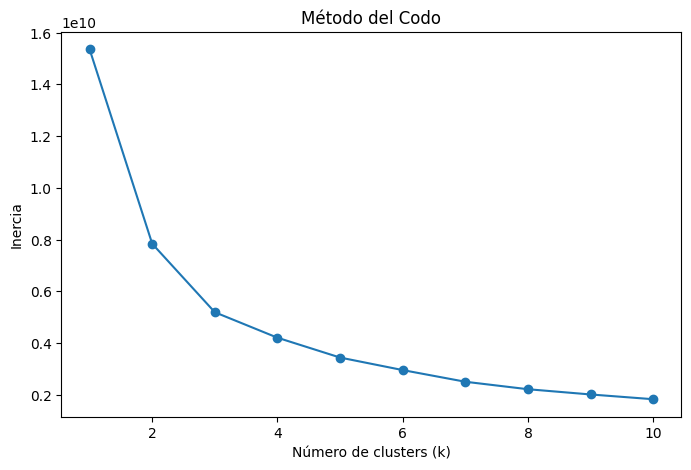

In [39]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# dataset limpio
df_cluster = df.dropna(subset=[
    "tasa_homicidios_100k",
    "TECNICA PROFESIONAL",
    "TECNOLOGICA",
    "UNIVERSITARIA"
])

# variables para clustering
X_cluster = df_cluster[[
    "tasa_homicidios_100k",
    "TECNICA PROFESIONAL",
    "TECNOLOGICA",
    "UNIVERSITARIA"
]]
# Variables para clustering
X_cluster = df_cluster[[
    "tasa_homicidios_100k",
    "TECNICA PROFESIONAL",
    "TECNOLOGICA",
    "UNIVERSITARIA"
]]
# Calcular inercia para diferentes k
inercia = []

K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_cluster)
    inercia.append(kmeans.inertia_)

# Graficar
plt.figure(figsize=(8,5))
plt.plot(K, inercia, marker='o')
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.title("Método del Codo")
plt.show()

Se observa una disminución pronunciada de la inercia hasta k=3. A partir de este punto, la reducción es mucho más gradual, lo que indica que agregar más clusters no mejora significativamente el modelo. Por lo tanto, se seleccionan 3 clusters como el número óptimo.

In [40]:

# KMEANS
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
df_cluster["cluster_kmeans"] = kmeans.fit_predict(X_cluster)

# resultados
print(df_cluster.groupby("cluster_kmeans")["tasa_homicidios_100k"].mean())

cluster_kmeans
0    31.181715
1    33.157204
2    34.566235
Name: tasa_homicidios_100k, dtype: float64


## Clustering jerárquico

Se aplica un método de clustering jerárquico para analizar la estructura de los datos y la relación entre observaciones.

El dendrograma permite visualizar cómo se agrupan los datos y sugiere la existencia de diferentes niveles de similitud entre los departamentos.

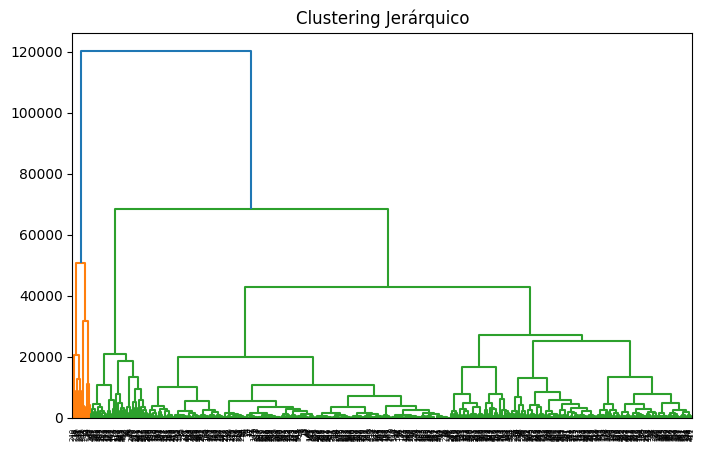

In [41]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

Z = linkage(X_cluster, method='ward')

plt.figure(figsize=(8,5))
dendrogram(Z)
plt.title("Clustering Jerárquico")
plt.show()

## Clustering con DBSCAN

Se aplica el algoritmo DBSCAN para identificar grupos basados en densidad y detectar posibles valores atípicos.

Los resultados muestran que la mayoría de los datos son clasificados como ruido (-1), lo que sugiere que no existen agrupaciones densas claras bajo los parámetros seleccionados.

In [42]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=10, min_samples=5)

df_cluster["cluster_dbscan"] = dbscan.fit_predict(X_cluster)

print(df_cluster["cluster_dbscan"].value_counts())

cluster_dbscan
-1    558
Name: count, dtype: int64


## Conclusiones

El problema principal del notebook no era que faltaran algoritmos, sino la forma de evaluacion y la falta de variables temporales. Al evitar fuga de informacion, codificar correctamente el departamento y agregar rezagos por departamento, el desempeño sobre 2021 queda mucho mas estable.

Tambien se confirma que un `R²` negativo si puede aparecer cuando el modelo predice peor que el promedio de la prueba; por eso se incluye una linea base de persistencia y se reportan varias metricas, no solo MAPE.